# Test 21: Quantization Robustness на активациях GPT-2

**Гипотеза:** Chaos activation даёт bounded output (~[-1.5, 1.5]), поэтому при агрессивной квантизации (2-3 bit) деградирует меньше ReLU. При каком-то bit depth chaos может обогнать ReLU по абсолютному loss.

**Из предыдущих тестов:**
- Тест 13 (MNIST): Chaos при 2-bit лучше ReLU при 4-bit
- Тест 18 (сигналы): Chaos деградация +0.1-2.7%, ReLU +1.6-22.4%
- Тест 19 (GPT-2, 4-bit): Chaos +0.3%, ReLU +4.1%

**План:**
- GPT-2 layer 6, 4x overcomplete, K=307
- Bit depths: 2, 3, 4, 6, 8
- N=5 прогонов, Chaos vs ReLU
- Найти точку пересечения — при каком bit depth chaos обгоняет ReLU по абсолютному loss

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import json
from datetime import datetime
import torch
from transformers import GPT2Model, GPT2Tokenizer
from datasets import load_dataset

print(f"TF version: {tf.__version__}")
print(f"GPU (TF): {tf.config.list_physical_devices('GPU')}")

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF version: 2.16.2
GPU (TF): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# === Извлечение активаций из GPT-2 layer 6 ===

print("Загрузка GPT-2 small...")
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_model = GPT2Model.from_pretrained('gpt2')
gpt2_model.eval()

ACTIVATION_DIM = 768
TARGET_LAYER = 6

print("Загрузка текстов...")
dataset = load_dataset('wikitext', 'wikitext-2-raw-v1', split='train')
texts = [t for t in dataset['text'] if len(t) > 100][:500]

print(f"Извлечение активаций из layer {TARGET_LAYER}...")
all_activations = []
tokenizer.pad_token = tokenizer.eos_token

with torch.no_grad():
    for i, text in enumerate(texts):
        inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128)
        outputs = gpt2_model(**inputs, output_hidden_states=True)
        hidden = outputs.hidden_states[TARGET_LAYER]
        acts = hidden.squeeze(0).numpy()
        all_activations.append(acts)
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(texts)}")

activations = np.concatenate(all_activations, axis=0).astype('float32')
act_mean = activations.mean(axis=0, keepdims=True)
act_std = activations.std(axis=0, keepdims=True) + 1e-8
activations_norm = ((activations - act_mean) / act_std).astype('float32')

np.random.seed(42)
indices = np.random.permutation(len(activations_norm))
split = int(len(indices) * 0.8)
x_train = activations_norm[indices[:split]]
x_test = activations_norm[indices[split:]]

del gpt2_model, tokenizer, all_activations
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print(f"Активации: {activations_norm.shape}, train={x_train.shape}, test={x_test.shape}")

Загрузка GPT-2 small...
Загрузка текстов...
Извлечение активаций из layer 6...
  100/500
  200/500
  300/500
  400/500
  500/500
Активации: (54573, 768), train=(43658, 768), test=(10915, 768)


In [3]:
# === SAE компоненты ===

class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(
            tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1
        )
        return inputs * mask

    def get_config(self):
        config = super().get_config()
        config.update({"k": self.k})
        return config


def chaos_activation(x):
    return tf.sin(1.0 * x) + 0.5 * tf.tanh(4.0 * x)


def build_sae(input_dim, latent_dim, k_active, use_chaos=True):
    input_act = keras.Input(shape=(input_dim,))
    if use_chaos:
        x = layers.Dense(latent_dim, name='latent_pre')(input_act)
        x = layers.Activation(chaos_activation)(x)
    else:
        x = layers.Dense(latent_dim, activation='relu', name='latent_pre')(input_act)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_act, latent, name='encoder')
    decoded = layers.Dense(input_dim, name='decoder')(latent)
    autoencoder = keras.Model(input_act, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def quantize_latents(latents, bits):
    """Min-max квантизация латентов до N бит."""
    q_latents = np.zeros_like(latents)
    levels = 2 ** bits - 1
    for i in range(latents.shape[0]):
        nz = np.where(np.abs(latents[i]) > 1e-10)[0]
        if len(nz) == 0:
            continue
        vals = latents[i, nz]
        vmin, vmax = vals.min(), vals.max()
        if vmax - vmin < 1e-10:
            q_latents[i, nz] = vals
            continue
        norm = (vals - vmin) / (vmax - vmin)
        q = np.round(norm * levels) / levels
        q_latents[i, nz] = q * (vmax - vmin) + vmin
    return q_latents


def build_decoder(autoencoder, latent_dim):
    """Извлечь декодер из автоэнкодера (слои после KSparse)."""
    decoder_input = keras.Input(shape=(latent_dim,))
    x = decoder_input
    found = False
    for layer in autoencoder.layers:
        if layer.name == 'latent_ksparse':
            found = True
            continue
        if found:
            x = layer(x)
    return keras.Model(decoder_input, x)


print("SAE + quantization ready.")

SAE + quantization ready.


In [4]:
# === Основной эксперимент: квантизация при разных bit depths ===

NUM_RUNS = 5
EPOCHS = 10
BATCH_SIZE = 256
INPUT_DIM = ACTIVATION_DIM  # 768
LATENT_DIM = INPUT_DIM * 4  # 3072
K_ACTIVE = LATENT_DIM // 10  # 307

BIT_DEPTHS = [2, 3, 4, 6, 8]

print(f"Config: input={INPUT_DIM}, latent={LATENT_DIM}, K={K_ACTIVE}")
print(f"Bit depths: {BIT_DEPTHS}")
print(f"Runs per method: {NUM_RUNS}\n")

results = {}

for method_name, use_chaos in [('Chaos_a1', True), ('TopK_ReLU', False)]:
    print(f"\n{'='*60}")
    print(f"  {method_name}")
    print(f"{'='*60}")
    
    method_runs = []
    
    for run in range(NUM_RUNS):
        np.random.seed(run)
        tf.random.set_seed(run)
        
        ae, enc = build_sae(INPUT_DIM, LATENT_DIM, K_ACTIVE, use_chaos=use_chaos)
        ae.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
               validation_data=(x_test, x_test), verbose=0)
        
        # Получаем латенты
        latents = enc.predict(x_test, verbose=0)
        val_loss = float(ae.evaluate(x_test, x_test, verbose=0))
        dead = int(np.sum(np.all(np.abs(latents) < 1e-6, axis=0)))
        
        # Извлекаем декодер
        decoder = build_decoder(ae, LATENT_DIM)
        
        # Квантизация при разных bit depths
        run_data = {
            'val_loss': val_loss,
            'dead': dead,
            'quant_losses': {},
        }
        
        for bits in BIT_DEPTHS:
            q_latents = quantize_latents(latents, bits)
            q_recon = decoder.predict(q_latents, verbose=0)
            q_loss = float(np.mean((x_test - q_recon) ** 2))
            run_data['quant_losses'][bits] = q_loss
        
        method_runs.append(run_data)
        
        print(f"  run {run+1}/{NUM_RUNS}: base={val_loss:.4f}, "
              + ", ".join([f"{b}bit={run_data['quant_losses'][b]:.4f}" for b in BIT_DEPTHS]))
        
        del ae, enc, decoder
        keras.backend.clear_session()
    
    results[method_name] = method_runs

print("\nAll experiments done.")

Config: input=768, latent=3072, K=307
Bit depths: [2, 3, 4, 6, 8]
Runs per method: 5


  Chaos_a1


2026-04-10 15:03:51.952270: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-10 15:03:51.952295: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-04-10 15:03:51.952298: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-04-10 15:03:51.952310: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-10 15:03:51.952320: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-10 15:03:52.330568: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  run 1/5: base=0.1647, 2bit=0.1790, 3bit=0.1691, 4bit=0.1652, 6bit=0.1647, 8bit=0.1647
  run 2/5: base=0.1644, 2bit=0.1786, 3bit=0.1686, 4bit=0.1649, 6bit=0.1644, 8bit=0.1644
  run 3/5: base=0.1644, 2bit=0.1786, 3bit=0.1687, 4bit=0.1650, 6bit=0.1644, 8bit=0.1644
  run 4/5: base=0.1644, 2bit=0.1788, 3bit=0.1687, 4bit=0.1649, 6bit=0.1644, 8bit=0.1644
  run 5/5: base=0.1650, 2bit=0.1797, 3bit=0.1693, 4bit=0.1655, 6bit=0.1650, 8bit=0.1650

  TopK_ReLU
  run 1/5: base=0.1562, 2bit=0.4368, 3bit=0.1867, 4bit=0.1626, 6bit=0.1566, 8bit=0.1563
  run 2/5: base=0.1567, 2bit=0.4280, 3bit=0.1858, 4bit=0.1630, 6bit=0.1571, 8bit=0.1567
  run 3/5: base=0.1560, 2bit=0.4436, 3bit=0.1862, 4bit=0.1625, 6bit=0.1563, 8bit=0.1560
  run 4/5: base=0.1561, 2bit=0.4373, 3bit=0.1849, 4bit=0.1624, 6bit=0.1564, 8bit=0.1561
  run 5/5: base=0.1561, 2bit=0.4526, 3bit=0.1874, 4bit=0.1628, 6bit=0.1564, 8bit=0.1561

All experiments done.


In [5]:
# === Сводная таблица ===

print("=" * 90)
print("QUANTIZATION ROBUSTNESS: SAE на GPT-2 (layer 6, 4x overcomplete, K=307)")
print("=" * 90)
print(f"{'Метод':<12} {'Base Loss':>10} " + " ".join([f"{b}-bit Loss" for b in BIT_DEPTHS]))
print('-' * 90)

summary = {}
for method in ['Chaos_a1', 'TopK_ReLU']:
    runs = results[method]
    base_mean = np.mean([r['val_loss'] for r in runs])
    base_std = np.std([r['val_loss'] for r in runs])
    
    summary[method] = {'base_mean': base_mean, 'base_std': base_std, 'bits': {}}
    
    line = f"{method:<12} {base_mean:.4f}±{base_std:.4f}"
    for bits in BIT_DEPTHS:
        q_mean = np.mean([r['quant_losses'][bits] for r in runs])
        q_std = np.std([r['quant_losses'][bits] for r in runs])
        degrad = (q_mean - base_mean) / base_mean * 100
        summary[method]['bits'][bits] = {
            'loss_mean': q_mean, 'loss_std': q_std, 'degrad_pct': degrad
        }
        line += f"  {q_mean:.4f}"
    print(line)

# Таблица деградации
print(f"\n{'Деградация %':<12} " + "  ".join([f"  {b}-bit" for b in BIT_DEPTHS]))
print('-' * 70)
for method in ['Chaos_a1', 'TopK_ReLU']:
    line = f"{method:<12}"
    for bits in BIT_DEPTHS:
        d = summary[method]['bits'][bits]['degrad_pct']
        line += f"  {d:>+7.1f}%"
    print(line)

# Абсолютное сравнение — кто лучше при каждом bit depth
print(f"\n{'Абсолютный loss':<15} {'Base':>8} " + "  ".join([f"  {b}-bit" for b in BIT_DEPTHS]))
print('-' * 70)
for method in ['Chaos_a1', 'TopK_ReLU']:
    line = f"{method:<15} {summary[method]['base_mean']:>8.4f}"
    for bits in BIT_DEPTHS:
        line += f"  {summary[method]['bits'][bits]['loss_mean']:>8.4f}"
    print(line)

# Точка пересечения
print("\n" + "=" * 60)
print("ТОЧКА ПЕРЕСЕЧЕНИЯ:")
print("=" * 60)
crossover_found = False
for bits in BIT_DEPTHS:
    chaos_loss = summary['Chaos_a1']['bits'][bits]['loss_mean']
    relu_loss = summary['TopK_ReLU']['bits'][bits]['loss_mean']
    winner = "CHAOS" if chaos_loss < relu_loss else "ReLU"
    diff = abs(chaos_loss - relu_loss) / relu_loss * 100
    marker = " <<<" if chaos_loss < relu_loss else ""
    print(f"  {bits}-bit: Chaos={chaos_loss:.4f}, ReLU={relu_loss:.4f} → {winner} лучше на {diff:.1f}%{marker}")
    if chaos_loss < relu_loss and not crossover_found:
        print(f"  *** CROSSOVER at {bits}-bit! Chaos обгоняет ReLU ***")
        crossover_found = True

if not crossover_found:
    print("  → Crossover не найден: ReLU лучше при всех bit depths")

QUANTIZATION ROBUSTNESS: SAE на GPT-2 (layer 6, 4x overcomplete, K=307)
Метод         Base Loss 2-bit Loss 3-bit Loss 4-bit Loss 6-bit Loss 8-bit Loss
------------------------------------------------------------------------------------------
Chaos_a1     0.1646±0.0002  0.1789  0.1689  0.1651  0.1646  0.1646
TopK_ReLU    0.1562±0.0003  0.4397  0.1862  0.1627  0.1566  0.1562

Деградация %   2-bit    3-bit    4-bit    6-bit    8-bit
----------------------------------------------------------------------
Chaos_a1         +8.7%     +2.6%     +0.3%     +0.0%     +0.0%
TopK_ReLU      +181.5%    +19.2%     +4.1%     +0.2%     +0.0%

Абсолютный loss     Base   2-bit    3-bit    4-bit    6-bit    8-bit
----------------------------------------------------------------------
Chaos_a1          0.1646    0.1789    0.1689    0.1651    0.1646    0.1646
TopK_ReLU         0.1562    0.4397    0.1862    0.1627    0.1566    0.1562

ТОЧКА ПЕРЕСЕЧЕНИЯ:
  2-bit: Chaos=0.1789, ReLU=0.4397 → CHAOS лучше на 59.3% 

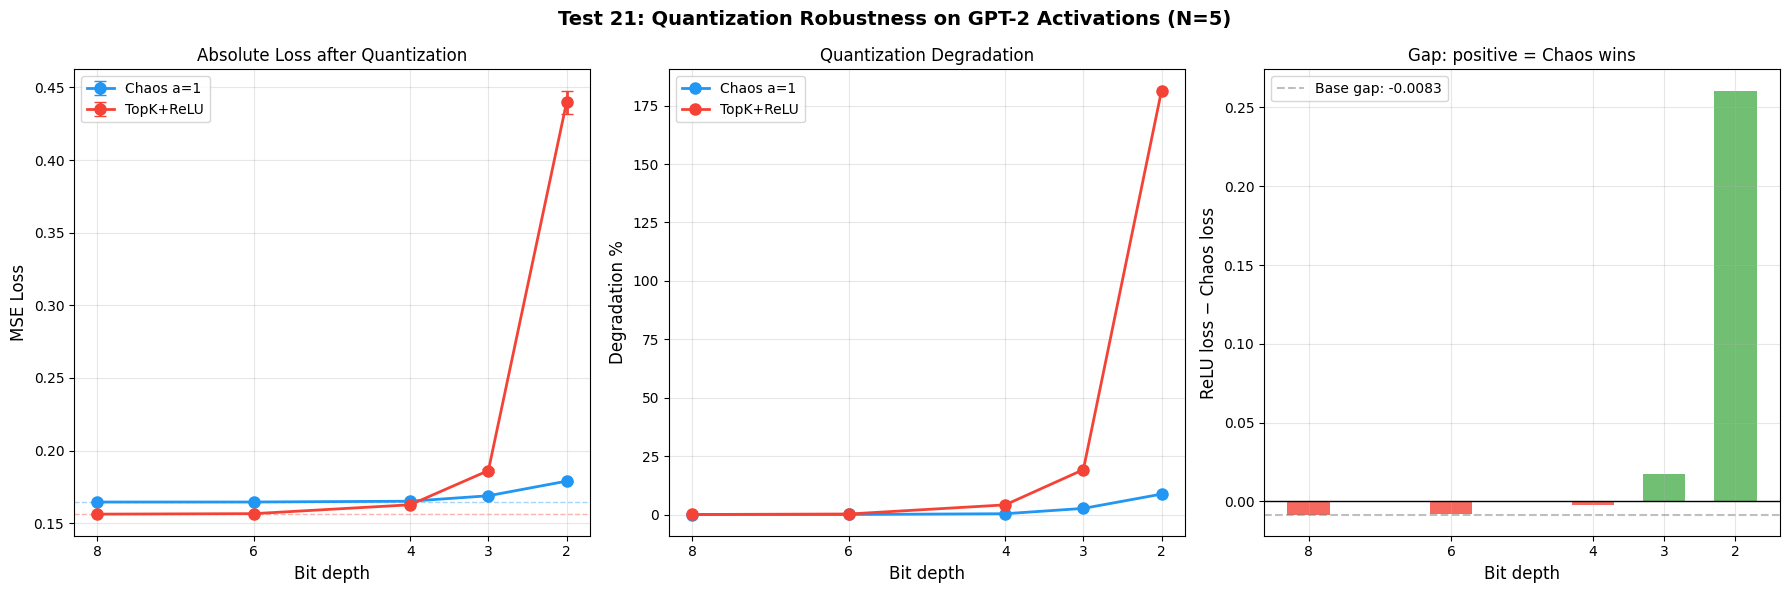

In [6]:
# === Визуализация ===

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = {'Chaos_a1': '#2196F3', 'TopK_ReLU': '#F44336'}
labels = {'Chaos_a1': 'Chaos a=1', 'TopK_ReLU': 'TopK+ReLU'}

# --- 1: Абсолютный loss по bit depth ---
for method in ['Chaos_a1', 'TopK_ReLU']:
    losses = [summary[method]['bits'][b]['loss_mean'] for b in BIT_DEPTHS]
    stds = [summary[method]['bits'][b]['loss_std'] for b in BIT_DEPTHS]
    axes[0].errorbar(BIT_DEPTHS, losses, yerr=stds, fmt='o-', color=colors[method],
                     lw=2, ms=8, capsize=4, label=labels[method])
    # Baseline (без квантизации)
    axes[0].axhline(y=summary[method]['base_mean'], color=colors[method],
                    ls='--', alpha=0.4, lw=1)

axes[0].set_xlabel('Bit depth', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Absolute Loss after Quantization')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(BIT_DEPTHS)
axes[0].invert_xaxis()

# --- 2: Деградация % по bit depth ---
for method in ['Chaos_a1', 'TopK_ReLU']:
    degrads = [summary[method]['bits'][b]['degrad_pct'] for b in BIT_DEPTHS]
    axes[1].plot(BIT_DEPTHS, degrads, 'o-', color=colors[method], lw=2, ms=8, label=labels[method])

axes[1].set_xlabel('Bit depth', fontsize=12)
axes[1].set_ylabel('Degradation %', fontsize=12)
axes[1].set_title('Quantization Degradation')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(BIT_DEPTHS)
axes[1].invert_xaxis()

# --- 3: Gap (ReLU loss - Chaos loss) по bit depth ---
gaps = []
for bits in BIT_DEPTHS:
    chaos_l = summary['Chaos_a1']['bits'][bits]['loss_mean']
    relu_l = summary['TopK_ReLU']['bits'][bits]['loss_mean']
    gaps.append(relu_l - chaos_l)  # positive = chaos лучше

base_gap = summary['TopK_ReLU']['base_mean'] - summary['Chaos_a1']['base_mean']
axes[2].bar(BIT_DEPTHS, gaps, color=['#4CAF50' if g > 0 else '#F44336' for g in gaps], alpha=0.8, width=0.6)
axes[2].axhline(y=0, color='black', lw=1)
axes[2].axhline(y=base_gap, color='gray', ls='--', alpha=0.5, label=f'Base gap: {base_gap:.4f}')
axes[2].set_xlabel('Bit depth', fontsize=12)
axes[2].set_ylabel('ReLU loss − Chaos loss', fontsize=12)
axes[2].set_title('Gap: positive = Chaos wins')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(BIT_DEPTHS)
axes[2].invert_xaxis()

plt.suptitle(f'Test 21: Quantization Robustness on GPT-2 Activations (N={NUM_RUNS})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

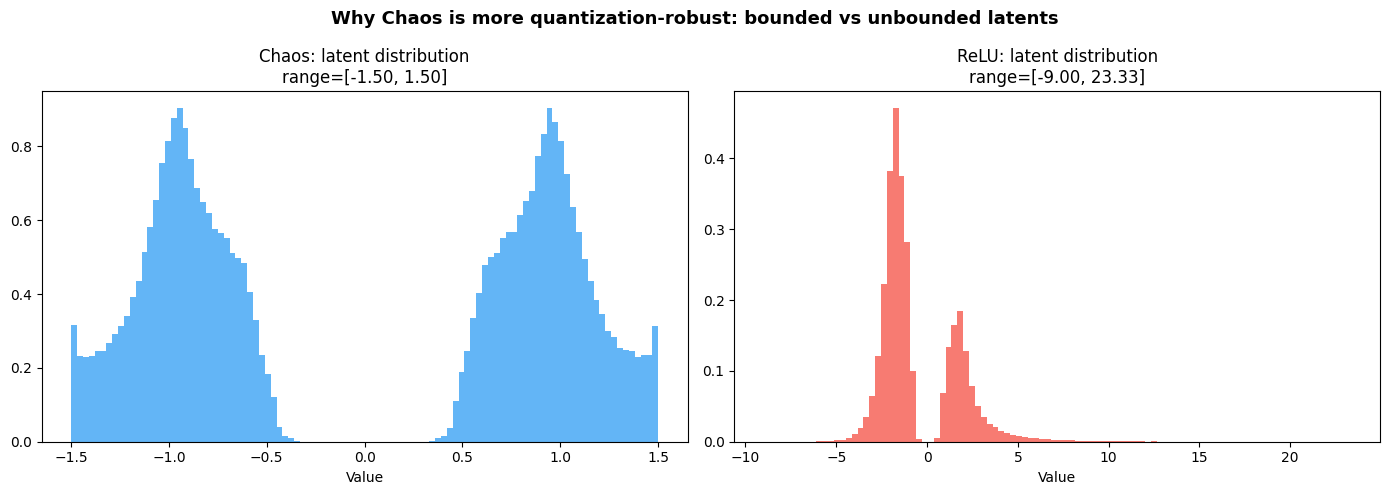

Chaos latent range: [-1.500, 1.500], std=0.977
ReLU  latent range: [-9.000, 23.328], std=2.191


In [7]:
# === Распределение латентов (для понимания почему chaos устойчивее) ===

# Обучим по одной модели для визуализации
np.random.seed(0)
tf.random.set_seed(0)
ae_c, enc_c = build_sae(INPUT_DIM, LATENT_DIM, K_ACTIVE, use_chaos=True)
ae_c.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
latents_chaos = enc_c.predict(x_test[:1000], verbose=0)

np.random.seed(0)
tf.random.set_seed(0)
ae_r, enc_r = build_sae(INPUT_DIM, LATENT_DIM, K_ACTIVE, use_chaos=False)
ae_r.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
latents_relu = enc_r.predict(x_test[:1000], verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ненулевые значения
nz_chaos = latents_chaos[np.abs(latents_chaos) > 1e-10]
nz_relu = latents_relu[np.abs(latents_relu) > 1e-10]

axes[0].hist(nz_chaos, bins=100, alpha=0.7, color='#2196F3', density=True)
axes[0].set_title(f'Chaos: latent distribution\nrange=[{nz_chaos.min():.2f}, {nz_chaos.max():.2f}]')
axes[0].set_xlabel('Value')

axes[1].hist(nz_relu, bins=100, alpha=0.7, color='#F44336', density=True)
axes[1].set_title(f'ReLU: latent distribution\nrange=[{nz_relu.min():.2f}, {nz_relu.max():.2f}]')
axes[1].set_xlabel('Value')

plt.suptitle('Why Chaos is more quantization-robust: bounded vs unbounded latents',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Chaos latent range: [{nz_chaos.min():.3f}, {nz_chaos.max():.3f}], std={nz_chaos.std():.3f}")
print(f"ReLU  latent range: [{nz_relu.min():.3f}, {nz_relu.max():.3f}], std={nz_relu.std():.3f}")

del ae_c, enc_c, ae_r, enc_r
keras.backend.clear_session()

In [8]:
# === Сохранение ===
save_data = {
    'experiment': 'llm_quantization_robustness',
    'timestamp': datetime.now().isoformat(),
    'config': {
        'llm_model': 'gpt2',
        'target_layer': TARGET_LAYER,
        'activation_dim': ACTIVATION_DIM,
        'latent_dim': LATENT_DIM,
        'k_active': K_ACTIVE,
        'bit_depths': BIT_DEPTHS,
        'num_runs': NUM_RUNS,
        'epochs': EPOCHS,
    },
    'results': results,
    'summary': summary,
}

json_path = f'../jsons/llm_quantization_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(json_path, 'w') as f:
    json.dump(save_data, f, indent=2, default=str)
print(f"Results saved: {json_path}")

Results saved: ../jsons/llm_quantization_20260410_151359.json
